In [22]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', '--quiet'], check=True)
print('Ready')

Ready



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [23]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load LSOA metadata
lsoas = pd.read_csv('data/test_lsoas.csv')
street_dir = 'data/images/'
aerial_dir = 'data/aerial_images/'

# Build street view records
sv_records = []
for fname in os.listdir(street_dir):
    if not fname.endswith('.jpg') or fname == 'test_image.jpg':
        continue
    lsoa_code = fname.rsplit('_', 1)[0]
    match = lsoas[lsoas['LSOA11CD'] == lsoa_code]
    if not match.empty:
        sv_records.append({
            'image_path': os.path.join(street_dir, fname),
            'lsoa': lsoa_code,
            'imd_score': float(match['IMD19'].values[0])
        })

sv_df = pd.DataFrame(sv_records)

# Build aerial records (one image per LSOA)
aerial_records = []
for fname in os.listdir(aerial_dir):
    if not fname.endswith('.jpg') or fname == 'test_aerial.jpg':
        continue
    lsoa_code = fname.replace('.jpg', '')
    match = lsoas[lsoas['LSOA11CD'] == lsoa_code]
    if not match.empty:
        aerial_records.append({
            'image_path': os.path.join(aerial_dir, fname),
            'lsoa': lsoa_code,
            'imd_score': float(match['IMD19'].values[0])
        })

aerial_df = pd.DataFrame(aerial_records)

# Find LSOAs present in BOTH modalities
sv_lsoas = set(sv_df['lsoa'].unique())
aerial_lsoas = set(aerial_df['lsoa'].unique())
common_lsoas = sorted(sv_lsoas & aerial_lsoas)

print(f'Street view images: {len(sv_df)} across {len(sv_lsoas)} LSOAs')
print(f'Aerial images: {len(aerial_df)} across {len(aerial_lsoas)} LSOAs')
print(f'LSOAs with both modalities: {len(common_lsoas)}')

Device: cpu
Street view images: 1708 across 427 LSOAs
Aerial images: 500 across 500 LSOAs
LSOAs with both modalities: 427


In [24]:
# ── Feature extraction helper ─────────────────────────────────────────────────
class ImageListDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)

def extract_embeddings(model, paths, transform, batch_size=32, desc=''):
    dataset = ImageListDataset(paths, transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    all_embs = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            emb = model(batch.to(device)).squeeze(-1).squeeze(-1)
            all_embs.append(emb.cpu().numpy())
            if (i+1) % 10 == 0:
                print(f'  {desc}: {(i+1)*batch_size}/{len(paths)}')
    return np.vstack(all_embs)

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

sv_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

aerial_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

print('Transforms ready')

Transforms ready


In [25]:
# ── Extract street view embeddings (ResNet-50) ────────────────────────────────
print('Loading ResNet-50 for street view...')
resnet = models.resnet50(weights='IMAGENET1K_V2')
sv_backbone = nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()
for p in sv_backbone.parameters():
    p.requires_grad = False

sv_df_common = sv_df[sv_df['lsoa'].isin(common_lsoas)].reset_index(drop=True)
sv_embs_all = extract_embeddings(sv_backbone, sv_df_common['image_path'].tolist(),
                                  sv_transform, desc='StreetView')
sv_df_common['emb_idx'] = range(len(sv_df_common))

# Mean pool street view embeddings per LSOA
sv_lsoa_embs = {}
for lsoa, group in sv_df_common.groupby('lsoa'):
    sv_lsoa_embs[lsoa] = sv_embs_all[group['emb_idx'].values].mean(axis=0)

print(f'Street view: {len(sv_lsoa_embs)} LSOA embeddings, dim={list(sv_lsoa_embs.values())[0].shape[0]}')

Loading ResNet-50 for street view...
  StreetView: 320/1708
  StreetView: 640/1708
  StreetView: 960/1708
  StreetView: 1280/1708
  StreetView: 1600/1708
Street view: 427 LSOA embeddings, dim=2048


In [26]:
# ── Extract aerial embeddings (EfficientNet-B2) ───────────────────────────────
print('Loading EfficientNet-B2 for aerial...')
efficientnet = models.efficientnet_b2(weights='IMAGENET1K_V1')
# Remove classifier, keep feature extractor
aerial_backbone = nn.Sequential(
    efficientnet.features,
    efficientnet.avgpool
).to(device).eval()
for p in aerial_backbone.parameters():
    p.requires_grad = False

aerial_df_common = aerial_df[aerial_df['lsoa'].isin(common_lsoas)].reset_index(drop=True)
aerial_embs_all = extract_embeddings(aerial_backbone, aerial_df_common['image_path'].tolist(),
                                      aerial_transform, desc='Aerial')

# One image per LSOA already — just map directly
aerial_lsoa_embs = {}
for i, row in aerial_df_common.iterrows():
    aerial_lsoa_embs[row['lsoa']] = aerial_embs_all[i]

print(f'Aerial: {len(aerial_lsoa_embs)} LSOA embeddings, dim={list(aerial_lsoa_embs.values())[0].shape[0]}')

Loading EfficientNet-B2 for aerial...
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /Users/sred/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35.2M/35.2M [00:01<00:00, 19.0MB/s]


  Aerial: 320/427
Aerial: 427 LSOA embeddings, dim=1408


In [27]:
# ── Fuse both modalities ──────────────────────────────────────────────────────
fused_X = []
fused_y = []
fused_lsoas = []

for lsoa in common_lsoas:
    sv_emb = sv_lsoa_embs[lsoa]        # (2048,)
    aerial_emb = aerial_lsoa_embs[lsoa] # (1408,) for EfficientNet-B2
    fused = np.concatenate([sv_emb, aerial_emb])  # (3456,)
    fused_X.append(fused)
    match = lsoas[lsoas['LSOA11CD'] == lsoa]
    fused_y.append(float(match['IMD19'].values[0]))
    fused_lsoas.append(lsoa)

X = np.array(fused_X)  # (N_lsoas, 3456)
y = np.array(fused_y)  # (N_lsoas,)

print(f'Fused feature matrix: {X.shape}')
print(f'Target: {y.shape}, range {y.min():.0f} to {y.max():.0f}')

Fused feature matrix: (427, 3456)
Target: (427,), range 1850 to 32451


In [28]:
# ── 5-Fold CV: PCA(50) + RidgeCV ─────────────────────────────────────────────
N_PCA = 50
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(y))
fold_r2s = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Standardise features (train only)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)

    # PCA (train only)
    pca = PCA(n_components=N_PCA, random_state=42)
    X_train_pca = pca.fit_transform(X_train_s)
    X_val_pca   = pca.transform(X_val_s)

    # Standardise target (train only)
    y_mean, y_std = y_train.mean(), y_train.std()
    y_train_n = (y_train - y_mean) / y_std

    # RidgeCV
    ridge = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5)
    ridge.fit(X_train_pca, y_train_n)

    preds = ridge.predict(X_val_pca) * y_std + y_mean
    oof_preds[val_idx] = preds

    r2 = r2_score(y_val, preds)
    fold_r2s.append(r2)
    print(f'Fold {fold+1}/5 | R² = {r2:.4f} | alpha = {ridge.alpha_:.2f}')

overall_r2 = r2_score(y, oof_preds)
print(f'\n=== Overall OOF R² = {overall_r2:.4f} ===')
print(f'Mean fold R²: {np.mean(fold_r2s):.4f} ± {np.std(fold_r2s):.4f}')

Fold 1/5 | R² = 0.2389 | alpha = 4291.93
Fold 2/5 | R² = 0.2434 | alpha = 4291.93
Fold 3/5 | R² = 0.2127 | alpha = 5689.87
Fold 4/5 | R² = 0.1305 | alpha = 4291.93
Fold 5/5 | R² = 0.1131 | alpha = 5689.87

=== Overall OOF R² = 0.1943 ===
Mean fold R²: 0.1877 ± 0.0551


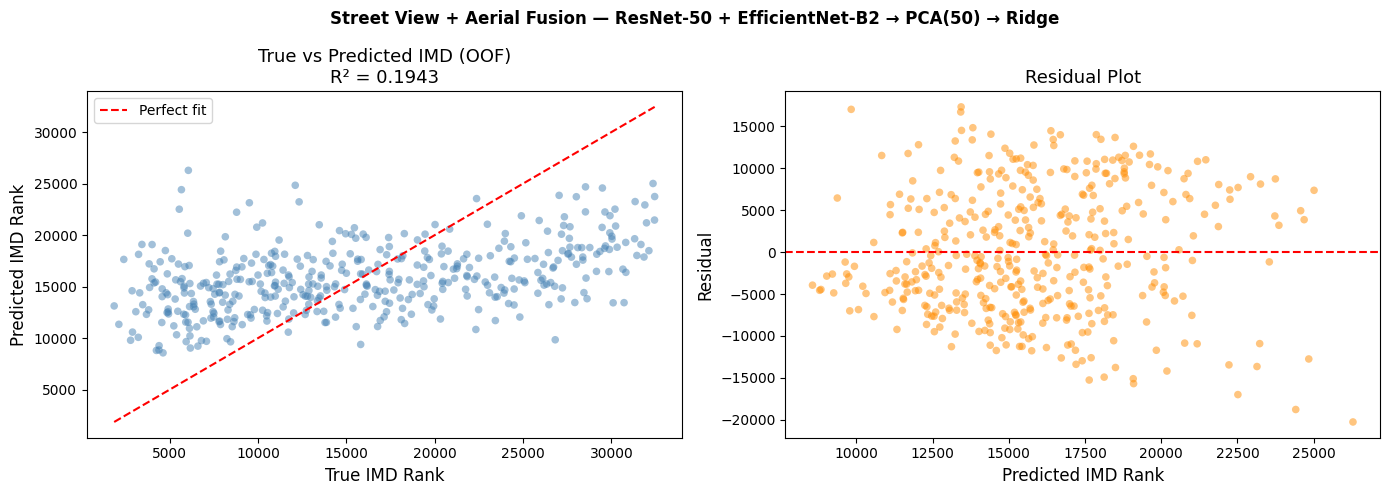

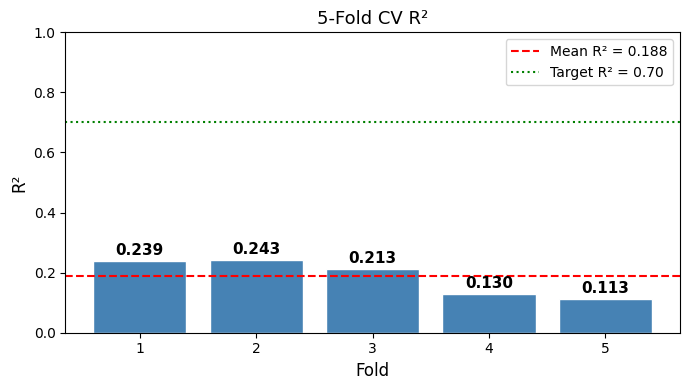

In [29]:
# ── Plots ─────────────────────────────────────────────────────────────────────
os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True vs predicted
axes[0].scatter(y, oof_preds, alpha=0.5, s=30, color='steelblue', edgecolors='none')
lims = [min(y.min(), oof_preds.min()), max(y.max(), oof_preds.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('True IMD Rank', fontsize=12)
axes[0].set_ylabel('Predicted IMD Rank', fontsize=12)
axes[0].set_title(f'True vs Predicted IMD (OOF)\nR² = {overall_r2:.4f}', fontsize=13)
axes[0].legend()

# Residuals
residuals = y - oof_preds
axes[1].scatter(oof_preds, residuals, alpha=0.5, s=30, color='darkorange', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted IMD Rank', fontsize=12)
axes[1].set_ylabel('Residual', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=13)

plt.suptitle('Street View + Aerial Fusion — ResNet-50 + EfficientNet-B2 → PCA(50) → Ridge',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fusion_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Fold R² bar chart
fig2, ax2 = plt.subplots(figsize=(7, 4))
bars = ax2.bar(range(1, 6), fold_r2s, color='steelblue', edgecolor='white')
ax2.axhline(np.mean(fold_r2s), color='red', linestyle='--', lw=1.5,
            label=f'Mean R² = {np.mean(fold_r2s):.3f}')
ax2.axhline(0.7, color='green', linestyle=':', lw=1.5, label='Target R² = 0.70')
for bar, v in zip(bars, fold_r2s):
    ax2.text(bar.get_x() + bar.get_width()/2, max(v + 0.01, 0.02),
             f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_xlabel('Fold', fontsize=12)
ax2.set_ylabel('R²', fontsize=12)
ax2.set_ylim(0, 1.0)
ax2.set_title('5-Fold CV R²', fontsize=13)
ax2.legend()
plt.tight_layout()
plt.savefig('outputs/fusion_fold_r2.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ── Save final model trained on all data ─────────────────────────────────────
os.makedirs('models', exist_ok=True)

final_scaler = StandardScaler()
X_all_s = final_scaler.fit_transform(X)

final_pca = PCA(n_components=N_PCA, random_state=42)
X_all_pca = final_pca.fit_transform(X_all_s)

y_mean_all, y_std_all = y.mean(), y.std()
y_norm_all = (y - y_mean_all) / y_std_all

final_ridge = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5)
final_ridge.fit(X_all_pca, y_norm_all)

# NOTE: This model bundle is superseded by models/final_spatial_bundle.pkl
with open('models/fusion_model_bundle.pkl', 'wb') as f:
    pickle.dump({
        'scaler': final_scaler,
        'pca': final_pca,
        'ridge': final_ridge,
        'y_mean': y_mean_all,
        'y_std': y_std_all
    }, f)

print(f'Final model saved to models/fusion_model_bundle.pkl')
print(f'Final Ridge alpha: {final_ridge.alpha_:.4f}')

Final model saved to models/fusion_model_bundle.pkl
Final Ridge alpha: 3237.4575
